In [4]:
import numpy as np
import matplotlib.pyplot as plt

z=0.0094

# use error column/ data quality

#readcol, 'SN2021fxy_nuv_20210329_1.dat', wave_nuv1_1, flux_nuv1_1, fluxerr_nuv1_1, dq_nuv1_1, format=('F,F,F,I')
#readcol, 'SN2021fxy_muv_20210329_1.dat', wave_muv1_1,  flux_muv1_1,  fluxerr_muv1_1,  dq_muv1_1,  format=('F,F,F,I')
#readcol, 'SN2021fxy_muv_20210329_2.dat', wave_muv1_2,  flux_muv1_2,  fluxerr_muv1_2,  dq_muv1_2,  format=('F,F,F,I')
#readcol, 'SN2021fxy_muv_20210329_3.dat', wave_muv1_3,  flux_muv1_3,  fluxerr_muv1_3,  dq_muv1_3,  format=('F,F,F,I')
#readcol, 'SN2021fxy_muv_20210330_1.dat', wave_muv1_4,  flux_muv1_4,  fluxerr_muv1_4,  dq_muv1_4,  format=('F,F,F,I')
#readcol, 'SN2021fxy_muv_20210330_2.dat', wave_muv1_5,  flux_muv1_5,  fluxerr_muv1_5,  dq_muv1_5,  format=('F,F,F,I')












In [95]:
def read_hst(infile): # Load the data from the file
    data = np.genfromtxt(infile, dtype={'names': ('wave', 'flux', 'fluxerr', 'dq'),'formats': (np.float16,np.float16,np.float16,np.uint)})
    # Access the individual columns from the loaded data
    wave    = data['wave']
    flux    = data['flux']
    fluxerr = data['fluxerr']
    dq      = data['dq']
    for d in dq:
        d=int(d)
    # Assuming dq is a NumPy array containing the elements you want to convert to binary
    # For example:
    # dq_nuv1_1 = np.array([3, 5, 10])

    # Calculate the number of elements in dq_opt1_1
    n = dq.shape[0]
    biggest=int(dq.max())
    biggestbits=biggest.bit_length()
    
    # Initialize an empty 2D array with rows equal to the number of bits in each element of dq_opt1_1
#    dqbits = np.zeros((dq.max().bit_length(), n), dtype=int)
#    dqbits = np.zeros((dq.bit_length(), n), dtype=int)
    dqbits = np.zeros((biggestbits, n), dtype=int)

    # Convert each element in dq_opt1_1 to binary and store the result in the corresponding column of dqbits_nuv1_1
    for i in range(n):
        dqbits[:, i] = np.binary_repr(dq[i])
    print(dqbits[:,0:19])
    # dqbits now contains the binary representation of each element of dq_nuv1_1
    print(dqbits[4,0:19])
    print("those were the dqbits")
    # Create a mask based on the specified conditions for dqbits_uv1_1
    mask = (dqbits[4, :] != 1) & (dqbits[6, :] != 1) & (dqbits[13, :] != 1)
    print(mask)
    # Use the mask to filter the wave_uv1_1 array
    wave_filtered = wave[mask]

    # wave_filtered will contain the elements from wave_uv1_1 where the corresponding elements in dqbits_uv1_1 satisfy the specified conditions

    flux_filtered = flux[mask]
    fluxerr_filtered = fluxerr[mask]
    return(wave_filtered, flux_filtered, fluxerr_filtered)



[[   101000000000    101000000000      1000000000 100001000010000
       1000000000      1000000000      1000000000      1000000000
       1000010000      1000000000      1000000000      1000000000
       1000010000      1000000000      1000010000      1000000000
       1000010000      1000010000 100001000010000]
 [   101000000000    101000000000      1000000000 100001000010000
       1000000000      1000000000      1000000000      1000000000
       1000010000      1000000000      1000000000      1000000000
       1000010000      1000000000      1000010000      1000000000
       1000010000      1000010000 100001000010000]
 [   101000000000    101000000000      1000000000 100001000010000
       1000000000      1000000000      1000000000      1000000000
       1000010000      1000000000      1000000000      1000000000
       1000010000      1000000000      1000010000      1000000000
       1000010000      1000010000 100001000010000]
 [   101000000000    101000000000      1000000000 10000

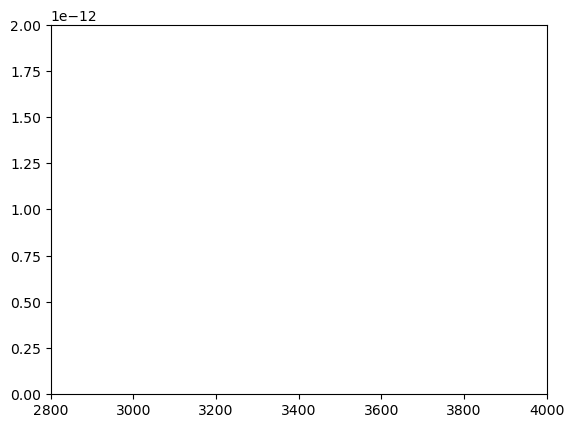

[0. 0. 0. ... 0. 0. 0.]


In [96]:
wave, flux, fluxerr = read_hst('SN2021fxy_nuv_20210329_1.dat')
plt.plot(wave, flux, '-', label = "2", alpha = 1, linewidth = .7)
#plt.yscale('log')
plt.xlim([2800,4000])
plt.ylim([0,2*10**(-12)])
#plt.ylim([10**(-16),10**(-14)])

#plt.legend()
#axes = plt.axes()
#axes.set_xlim([1600,5600])
#axes.set_ylim([10**(-16),10**(-14)])
plt.show()
print(flux)

In [42]:
data = np.genfromtxt('SN2021fxy_nuv_20210329_1.dat', dtype={'names': ('wave', 'flux', 'fluxerr', 'dq'),'formats': (np.float16,np.float16,np.float16,np.uint)})

In [23]:
print(data[3,:])


[ 2.90008315e+03 -8.31257210e-15  3.44523390e-15  1.69120000e+04]


In [61]:
num = -7
print(num.bit_length())

3


In [69]:
num=16912
print(num.bit_length())

15
